#  **Quality Control: Defect Detection in Manufacturing Images**

## **Problem Statement**

In modern manufacturing industries, maintaining product quality is critical to ensure reliability, safety, and customer satisfaction. Traditional quality inspection methods rely heavily on manual visual inspection, which is time-consuming, inconsistent, and prone to human error.

The objective of this project is to develop an automated defect detection system using machine learning techniques. The system analyzes surface images of manufactured materials and classifies them into different defect categories such as Crazing, Inclusion, Patches, Pitted Surface, Rolled-in Scale, and Scratches.

Using the NEU Surface Defect Database, this project applies image preprocessing, feature engineering, and multiple machine learning models to accurately identify defects. The final system is deployed as an interactive web application, allowing users to upload images and receive real-time predictions.

This solution aims to improve efficiency, reduce inspection time, and enhance the overall quality control process in manufacturing environments.

## **Real-World Motivation**

In manufacturing industries such as steel production, automotive, and electronics, surface defects can significantly impact product quality and safety. Even small defects may lead to product failure, increased maintenance costs, and customer dissatisfaction.

Manual inspection is widely used but has several limitations. It is slow, inconsistent, and depends heavily on human expertise, which may vary over time. As production scales increase, manual inspection becomes inefficient and costly.

Therefore, there is a strong need for an automated system that can quickly and accurately detect defects in manufacturing images.

## **Why Automation is Needed**

Automation in defect detection offers several advantages:

- **Speed:** Machines can analyze images much faster than humans.
- **Consistency:** Eliminates human errors and fatigue-related mistakes.
- **Scalability:** Can handle large volumes of production data efficiently.
- **Cost Reduction:** Reduces dependency on manual labor.
- **Real-Time Monitoring:** Enables immediate detection and response.

By leveraging machine learning, the system can learn patterns from data and improve detection accuracy over time, making it highly suitable for modern industrial applications.

# **EDA (Exploratory Data Analysis)**

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset

In [2]:
import pandas as pd

df = pd.read_csv(r"/content/dataset.csv")

df.head()

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,4096
0,175,196,202,155,195,180,160,168,208,165,...,137.0,129.0,145.0,143.0,142.0,175.0,159.0,142.0,137.0,crazing
1,169,192,205,216,177,179,217,190,200,218,...,89.0,110.0,105.0,108.0,96.0,84.0,86.0,87.0,71.0,crazing
2,102,95,96,108,132,118,137,135,116,109,...,114.0,93.0,92.0,106.0,105.0,102.0,106.0,92.0,85.0,crazing
3,152,174,191,158,141,176,150,171,148,145,...,189.0,208.0,164.0,149.0,164.0,166.0,164.0,162.0,135.0,crazing
4,167,184,126,113,159,140,157,128,146,154,...,59.0,59.0,53.0,51.0,49.0,40.0,49.0,25.0,48.0,crazing


In [3]:
df.shape

(1376, 4097)

In [4]:
df.iloc[:, -1].value_counts()

,count
4096,
crazing,300
inclusion,300
patches,300
pitted_surface,300
rolled-in_scale,175


### Class distribution

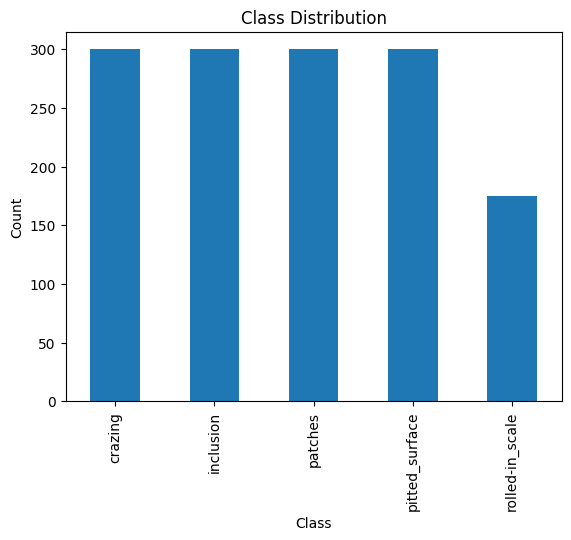

In [8]:
import os
import matplotlib.pyplot as plt

# Create output folder (safe even if it already exists)
os.makedirs("/content/outputs", exist_ok=True)

df.iloc[:, -1].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig("/content/outputs/class_distribution.png")  # save first
plt.show()                                               # then display
plt.close()                                              # then free memory

# **Preprocessing**

In [9]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
4092,1
4093,1
4094,1
4095,1


In [10]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

### Normalize data
This improves model performance

In [11]:
X = X / 255.0

### Histogram

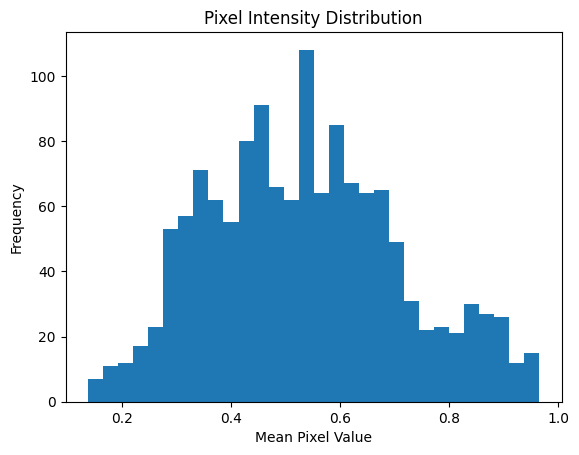

In [13]:
import os
import matplotlib.pyplot as plt

# Create folder if it doesn't exist
os.makedirs("../outputs/plots", exist_ok=True)

# Mean pixel value per image
pixel_mean = X.iloc[:, :4096].mean(axis=1)

plt.figure()
plt.hist(pixel_mean, bins=30)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Mean Pixel Value")
plt.ylabel("Frequency")

plt.savefig("../outputs/plots/histogram.png")  # save first
plt.show()                                      # then display
plt.close()                                     # then free memory

### Boxplot

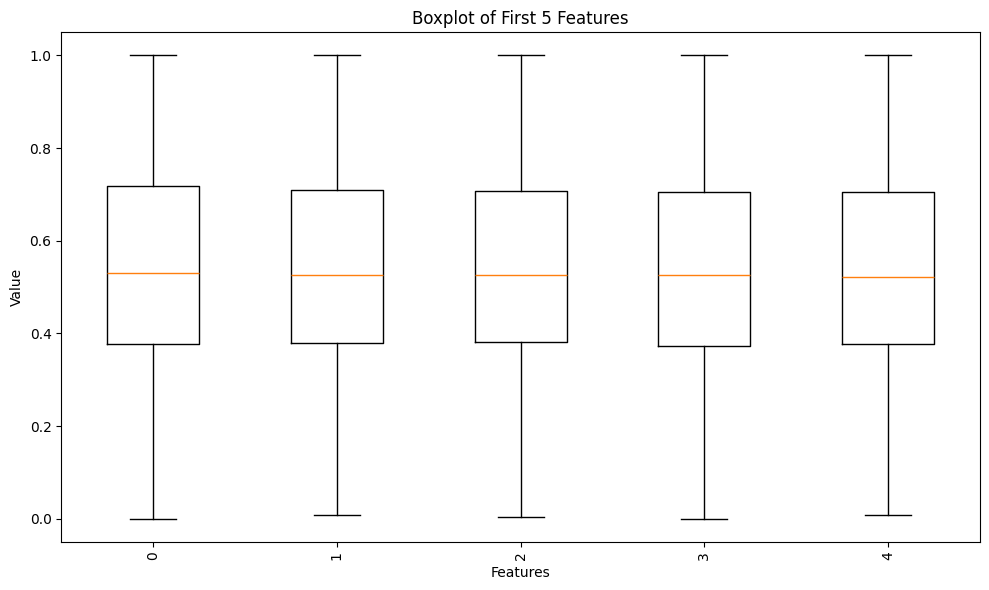

In [19]:
import os
import matplotlib.pyplot as plt

# Create folder if it doesn't exist
os.makedirs("../outputs/plots", exist_ok=True)

plt.figure(figsize=(10, 6))

# Take only a few features (important!)
plt.boxplot(X.iloc[:, :5].values)

plt.title("Boxplot of First 5 Features")

# Use actual column names if available, else fallback to Feature 0..4
try:
    labels = X.columns[:5].tolist()
    # if columns are just integers like 0,1,2,3,4 → use Feature names instead
    if all(isinstance(c, int) for c in labels):
        labels = [f"Feature {i}" for i in range(5)]
except Exception:
    labels = [f"Feature {i}" for i in range(5)]


plt.xticks(ticks=range(1, 6), labels=labels, rotation=90)
plt.ylabel("Value")
plt.xlabel("Features")
plt.tight_layout()                                               # prevents label cutoff
plt.savefig("../outputs/plots/boxplot.png", bbox_inches="tight")
plt.show()
plt.close()

### Correlation Matrix

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

# Using only first 50 columns (important for performance)
sns.heatmap(X.iloc[:, :50].corr(), cmap='coolwarm')

plt.title("Correlation Matrix")
plt.savefig("../outputs/plots/correlation_matrix.png")
plt.close()

# **Feature Engineering**

In [22]:
mean_pixel = X.mean(axis=1)
std_pixel = X.std(axis=1)

import pandas as pd
X = pd.concat([X, mean_pixel.rename('mean_pixel'), std_pixel.rename('std_pixel')], axis=1)

In [23]:
import cv2
import numpy as np

def extract_edges(row):
    pixels = row.iloc[:4096]   # ALWAYS take first 4096 values
    img = np.array(pixels).reshape(64, 64)

    edges = cv2.Canny(img.astype('uint8'), 100, 200)
    return edges.mean()

X['edge_feature'] = X.apply(extract_edges, axis=1)

/tmp/ipykernel_2846/1648910712.py:8: RuntimeWarning: invalid value encountered in cast
  edges = cv2.Canny(img.astype('uint8'), 100, 200)


## Save processed dataset

In [26]:
import os

# Create folder if it doesn't exist
os.makedirs("../data", exist_ok=True)

processed_df = X.copy()
processed_df['label'] = y

processed_df.to_csv("../data/processed_dataset.csv", index=False)

print("✅ Processed dataset saved!")

✅ Processed dataset saved!
